# Experiment I.2: Goodness of fit and variance of beta

In this notebook we continue examining beta as a fitting parameter, and we look more closely at the measures of goodness of fit (GOF) to get an idea of the uncertainties in the fitting proces.

In [1]:
# General imports
import numpy as np
import scipy
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Insert path of source folder
import sys
from pathlib import Path
root_dir = Path.cwd().parent
sys.path.insert(0, str(root_dir / "src"))

# And import the Package:
import beta_ensembles as be

# Default plotting style
plt.style.use(['seaborn-v0_8','./plot_style.mplstyle'])

# Default path to save figures
def savefig(fname):
    plt.savefig(str(Path.cwd().parent) + '\\figures\\' + fname + '.png')

# Part II: Goodness of fit and confidence bounds on beta

We'll examine two statistics for the goodness of fit. One is the log-likelihood that is maximized by the fitting process. From it we can determine a value of the sigma confidence bound on the fitted beta, given the fitting process. Then, we verify the goodness of fit using another, independent statistic, the Cramèr-von Mises, and compare the results.

As before, let's consider a large sample of matrices of N = 100 or N = 1000. In the latter case, the notebook is slower to run.

We'll fix beta = 2 for this example.

We will also work with the unfolded eigenvalues, and, to make sure edge effects do not affect our result, restrict ourselves to the 80% of eigenvalues in the bulk, removing the smallest and largest 10% of eigenvalues from each sample before fitting.

In [2]:
# Parameters
beta = 2.0
n_spectra = 5000

# Choose N:
N = 100
# N = 1000

# We add N dependence to RNG so the two samples are completely uncorrelated
rng = np.random.default_rng(seed=sum(b"Natsume Soseki")+N)

# No. of "edge" eigenvalues to discard before computing ratios:
cutoff = round(N/10)

spectra = be.gaussian.unfold(be.gaussian.spectra(beta,N,n_spectra,rng=rng))
ratios = be.ratios(spectra[:,cutoff:-cutoff])

Generating GBE spectra: 100%|████████████████████████████████████████████████████| 5000/5000 [00:02<00:00, 2239.86it/s]


We plot the histogram of spacing ratios with the GUE distribution. It looks nearly a perfect fit. We will see how well that translates for the GOF measures in the following.

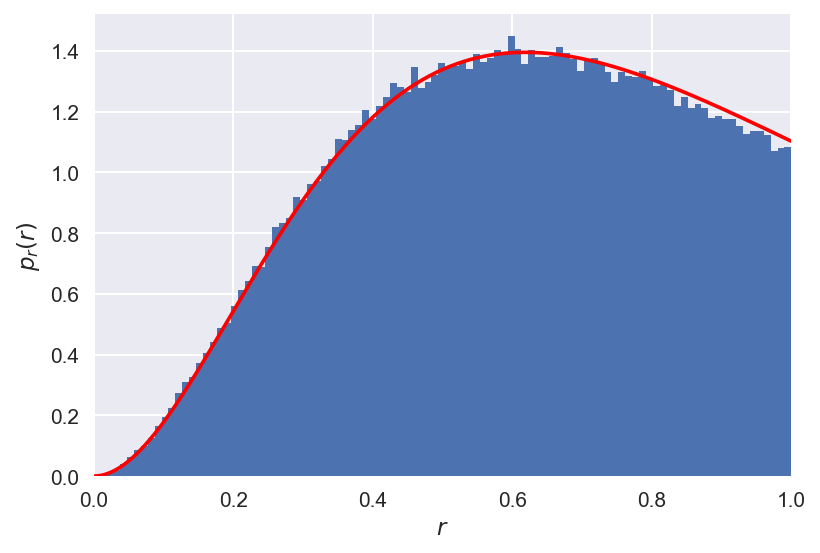

In [3]:
be.plot.hist_r(ratios)
be.plot.pdf_r(beta,c='r');

We define/import the two statistics we use, the log-likelihood (the measure maximized by the fitting algorithm), and the Cramér-von Mises statistic. We also define helper functions to compute them on a given set of ratios and for a given value or range of values for beta.

In [4]:
from scipy.stats import cramervonmises as cvm

def log_likelihood(beta, ratios):
    return np.sum(np.log(be.statistics.pdf_r(beta,ratios.ravel())))

# Compute log-likelihood for a set of ratios for a given array of beta values:
def get_ll(ratios,beta_grid):
    if isinstance(beta_grid,float):
        beta_grid = [beta_grid]
    beta_grid = np.asarray(beta_grid)
    ratios = ratios.ravel()
    
    ll = np.zeros(beta_grid.shape)
    
    for i, b in enumerate(beta_grid):
        ll[i] = log_likelihood(b,ratios)

    return ll

# Compute CVM for a set of ratios for a given array of beta values:
def get_cvm(ratios,beta_grid):
    if isinstance(beta_grid,float):
        beta_grid = [beta_grid]
    beta_grid = np.asarray(beta_grid)
    ratios = ratios.ravel()
    
    cs = np.zeros(beta_grid.shape)
    cp = np.zeros(beta_grid.shape)
    
    for i, b in enumerate(beta_grid):
        cdf = lambda r: be.statistics.cdf_r(b,r)
        cvm_res = cvm(ratios,cdf)
        cs[i] = cvm_res.statistic
        cp[i] = cvm_res.pvalue

    return cs, cp

We can see the dependence on sample size by fitting subsets of different sizes as well as fitting the full sample of ratios.

We choose the three "groups" to be the first 1000 spectra, the first 2000 spectra, and the full sample of 5000 spectra.

Fitting the best value of beta in each group, we see that the fitted values are a little below the input value of 2, with small variances in the result.

In [5]:
groups = [range(1000),range(2000),range(5000)]
n_g = len(groups)
beta_fit = np.zeros(n_g)

for i, g in enumerate(groups):
    beta_fit[i] = be.fit_ratios(ratios[g])

print('The fitted values of beta for the samples of size 1000, 2000, and 5000 are:')
print(f'{beta_fit}')

The fitted values of beta for the samples of size 1000, 2000, and 5000 are:
[1.95390625 1.94658203 1.94462891]


Next we compute the two statistics, log-likelihood and CvM, for the three groups separately. From a quadratic fit to the log-likelihood around the mimimum we extract the value of the standard deviation sigma.

We plot both on a grid of beta values around beta_fit:

In [6]:
# Can lower the range or resolution on the grid of beta for faster performance. Here the resolution is high for the sake of the plots.
n_beta = 101
beta_grid = np.linspace(1.9,2.02,n_beta)

ll = np.zeros((n_g,n_beta))
cc = np.zeros((n_g,n_beta))
sigma = np.zeros(n_g)

cvm_s = np.zeros((n_g,n_beta))
cvm_p = np.zeros((n_g,n_beta))

for i, g in enumerate(tqdm(groups)):
    ll[i] = get_ll(ratios[g],beta_grid)
    # We write the results relative to the log-likelihood at beta_fit of the full sample
    ll[i] = ll[i] - log_likelihood(beta_fit[-1],ratios[g])
    sigma[i] = 1/np.sqrt(-2*np.polyfit(beta_grid, ll[i], 2)[0])

    cvm_s[i], cvm_p[i] = get_cvm(ratios[g],beta_grid)

  0%|          | 0/3 [00:00<?, ?it/s]

The results are printed below. They are also in table 6.1 in our note:

In [7]:
# Results in LaTeX format

print('Beta values')
for i, g in enumerate(groups):
    print(rf'{beta_fit[i]:.3f} $\pm$ {sigma[i]:.3f}')

print('\nCVM at fitted Beta values')
for i, g in enumerate(groups):
    print(rf'{get_cvm(ratios[g],beta_fit[i])[0][0]:.3f}')

print('\nCVM p at fitted Beta values')
for i, g in enumerate(groups):
    print(rf'{get_cvm(ratios[g],beta_fit[i])[1][0]:.3f}')

Beta values
1.954 $\pm$ 0.013
1.947 $\pm$ 0.009
1.945 $\pm$ 0.006

CVM at fitted Beta values
0.305
0.811
1.533

CVM p at fitted Beta values
0.131
0.007
0.000


Next we find numerically what is the beta values that minimizes the CVM measure.

(Note that for the large N = 1000 sample this returns a warning, presumably because of the very large number of data points. Still, the correct value is found, as can be seen from comparing with a plot.)

In [8]:
beta_cvm = np.zeros(n_g)
min_cvm_s = np.zeros(n_g)
max_cvm_p = np.zeros(n_g)

for i, g in enumerate(groups):
    cvm_func = lambda b: get_cvm(ratios[g],b)[0]
    beta_cvm[i] = (scipy.optimize.minimize(cvm_func,beta_fit[i]).x)[0]
    cs, cp = get_cvm(ratios[g],beta_cvm[i])
    min_cvm_s[i] = cs[0]
    max_cvm_p[i] = cp[0]

Write the results, also found in table 6.1:

In [9]:
print('\nBeta_CvM:')
for i, g in enumerate(groups):
    print(rf'{beta_cvm[i]:.3f}')

print('\nCVM at Beta_CVM values')
for i, g in enumerate(groups):
    print(rf'{get_cvm(ratios[g],beta_cvm[i])[0][0]:.3f}')

print('\nCVM p at Beta_CVM values')
for i, g in enumerate(groups):
    print(rf'{get_cvm(ratios[g],beta_cvm[i])[1][0]:.3f}')


Beta_CvM:
1.933
1.923
1.924

CVM at Beta_CVM values
0.144
0.388
0.746

CVM p at Beta_CVM values
0.410
0.078
0.010


Let's plot the results for the log-likelihood and CvM side-by-side.

This generates figure 6.3 in the note.

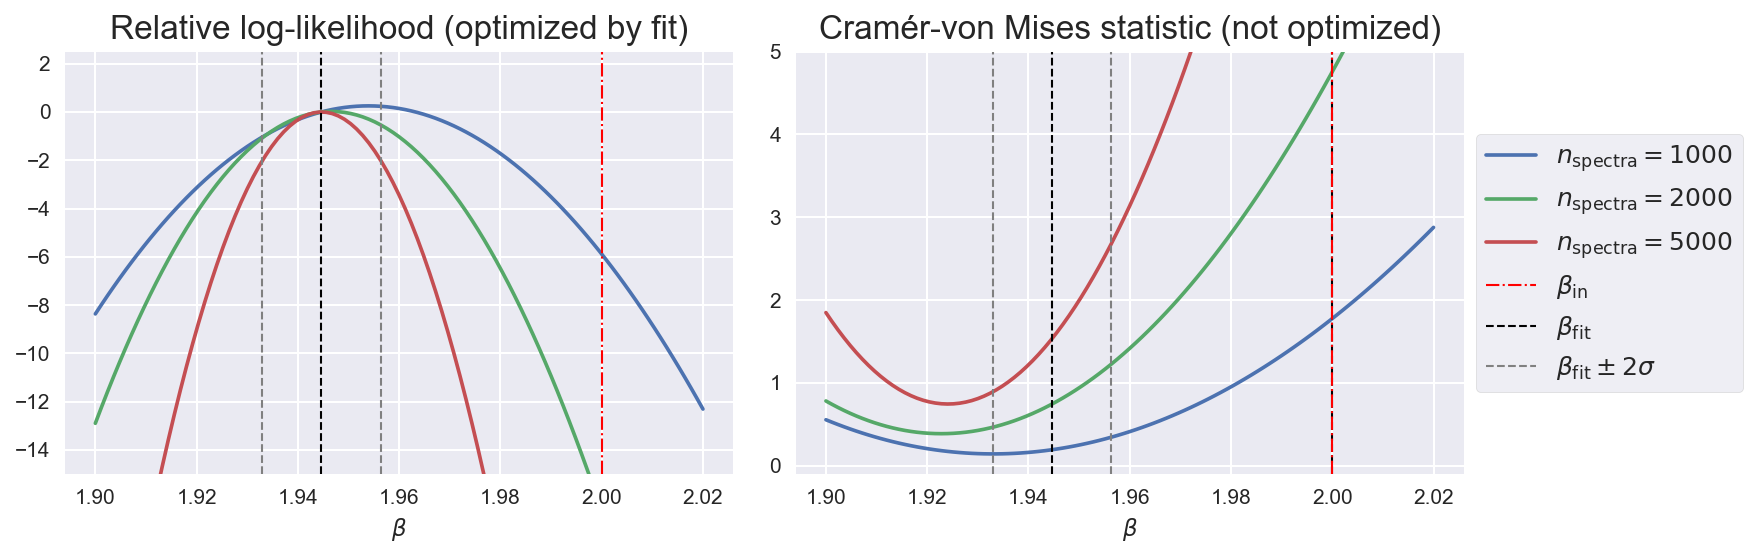

In [10]:
plt.subplots(1,2,figsize=(12,4))

for i in range(n_g):
    plt.subplot(1,2,1)
    plt.plot(beta_grid,ll[i],label=rf'$n_\text{{spectra}} = {groups[i][-1]+1}$')
    
    plt.subplot(1,2,2)
    plt.plot(beta_grid,cvm_s[i],label=rf'$n_\text{{spectra}} = {groups[i][-1]+1}$')

plt.subplot(1,2,1)
plt.title('Relative log-likelihood (optimized by fit)')
plt.axvline(beta,c='r',ls='-.',lw=1,label=r'$\beta_\text{in}$')
plt.axvline(beta_fit[-1],c='k',ls='--',lw=1,label=r'$\beta_\text{fit}$')
plt.axvline(beta_fit[-1]+2*sigma[-1],c='gray',ls='--',lw=1,label=r'$\beta_\text{fit}\pm \sigma$')
plt.axvline(beta_fit[-1]-2*sigma[-1],c='gray',ls='--',lw=1)
plt.ylim(-15,2.5)
plt.xlabel(r'$\beta$')

plt.subplot(1,2,2)
plt.title('Cramér-von Mises statistic (not optimized)')
plt.axvline(beta,c='k',ls='--',lw=1)
plt.axvline(beta,c='r',ls='-.',lw=1,label=r'$\beta_\text{in}$')
plt.axvline(beta_fit[-1],c='k',ls='--',lw=1,label=r'$\beta_\text{fit}$')
plt.axvline(beta_fit[-1]+2*sigma[-1],c='gray',ls='--',lw=1,label=r'$\beta_\text{fit}\pm 2\sigma$')
plt.axvline(beta_fit[-1]-2*sigma[-1],c='gray',ls='--',lw=1)
plt.ylim(-0.1,5)

plt.xlabel(r'$\beta$')

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()

# savefig(f'1c_{N}_temp.png')

We can plot the difference between the measured and expected CDF for the two values of beta, the one that was chosen by the fitting algorithm versus the one that minimizes CVM. We pick the values for the full sample of 5000 spectra.

For the latter, we can see the CDF is much closer, as expected. The CVM attempts to minimize the difference in the CDFs. On the other hand, the beta found by maximizing the log-likelihood gives a better fit at small values of r.

There is no reason to prefer one measure over the other as giving the "definitive" choice of beta.

This is figure 6.4 in the note.

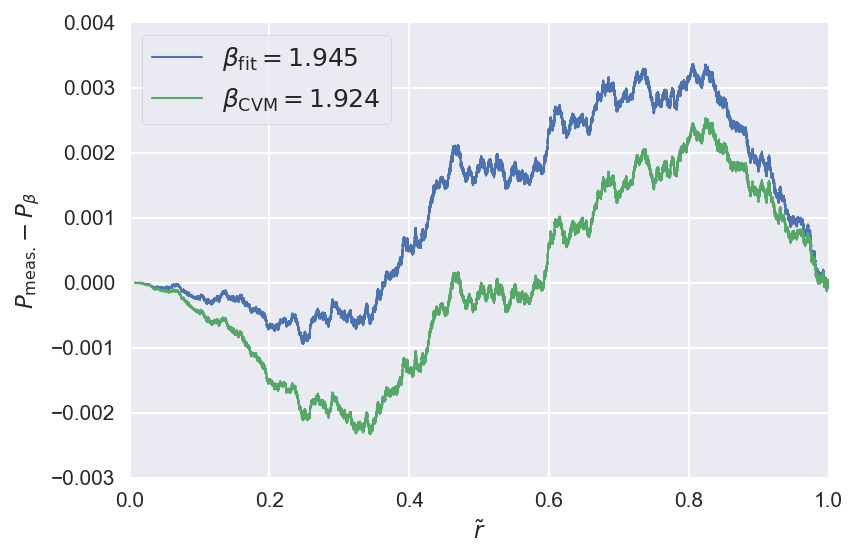

In [11]:
r_n = np.sort(ratios.ravel())

n_r = r_n.size
cdf_e = (1+np.arange(n_r)) / n_r

cdf_1 = be.statistics.cdf_r(beta_fit[-1],r_n)
cdf_2 = be.statistics.cdf_r(beta_cvm[-1],r_n)

plt.plot(r_n,cdf_e-cdf_1,lw=1,label=rf'$\beta_\text{{fit}} = {beta_fit[-1]:.3f}$');
plt.plot(r_n,cdf_e-cdf_2,lw=1,label=rf'$\beta_\text{{CVM}} = {beta_cvm[-1]:.3f}$');

plt.xlabel(r'${{\tilde r}}$');
plt.ylabel(r'$P_\text{meas.} - P_\beta$');
plt.xlim(0,1)
plt.ylim(-0.003,0.004)

plt.legend(loc='upper left');

plt.tight_layout()

# savefig(f'1d_{N}_temp.png')